In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
import pandas as pd
import zipfile
import os
import pathlib
import numpy as np
from google.colab import files
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
import warnings
import cv2

In [ ]:
from google.colab import files
uploaded = files.upload("C:\\Users\\vicky\\Downloads\\Dataset.csv")


In [27]:
df = pd.read_csv("/content/output_folder/train/_annotations.csv")
print(df.head())


                                            filename  width  height   class  \
0  BikesHelmets100_png.rf.54dfe2ef60e8f48d3088cca...    640     640  helmet   
1  BikesHelmets100_png.rf.54dfe2ef60e8f48d3088cca...    640     640  helmet   
2  BikesHelmets135_png.rf.051ae3c9b39d83de3ecd614...    640     640  helmet   
3  BikesHelmets135_png.rf.051ae3c9b39d83de3ecd614...    640     640  helmet   
4  BikesHelmets13_png.rf.8d943cc63cf9a6aa539fa6e2...    640     640  helmet   

   xmin  ymin  xmax  ymax  
0   170    31   243   132  
1   250    38   323   145  
2   240    21   387   120  
3   115    27   230    99  
4   299    37   380   164  


In [28]:
classes = df['class'].unique()
class_to_id = {c:i for i,c in enumerate(classes)}
NUM_CLASSES = len(classes)

print(class_to_id)


{'helmet': 0}


In [42]:
import tensorflow as tf
IMG_SIZE = 224

images = []
bboxes = []
labels = []

for _, row in df.iterrows():
    img_path = os.path.join("/content/output_folder/train", row['filename'])
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w, _ = img.shape

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # Normalize bounding box
    xmin = row['xmin'] / w
    ymin = row['ymin'] / h
    xmax = row['xmax'] / w
    ymax = row['ymax'] / h

    x_center = (xmin + xmax) / 2
    y_center = (ymin + ymax) / 2
    bw = xmax - xmin
    bh = ymax - ymin

    images.append(img)
    bboxes.append([x_center, y_center, bw, bh])
    labels.append(class_to_id[row['class']])

X = np.array(images)
y_bbox = np.array(bboxes, dtype=np.float32)
y_class = np.ones((len(labels), 1), dtype=np.float32)



In [44]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = tf.keras.layers.Conv2D(32, 3, activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, 3, activation='relu')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, 3, activation='relu')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)

bbox_output = tf.keras.layers.Dense(4, activation='sigmoid', name="bbox")(x)
class_output = tf.keras.layers.Dense(1, activation='sigmoid', name="class")(x)


model = tf.keras.Model(inputs, [class_output, bbox_output])


In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss={
        "class": "binary_crossentropy",
        "bbox": "mse"
    },
    metrics={"class": "accuracy"}
)


In [40]:
print("Total rows in CSV:", len(df))
print("Images loaded:", len(images))
print("X shape:", np.array(images).shape)


Total rows in CSV: 19
Images loaded: 19
X shape: (19, 224, 224, 3)


In [47]:
model.fit(
    X,
    {"class": y_class, "bbox": y_bbox},
    epochs=20,
    batch_size=8
)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 939ms/step - bbox_loss: 0.1463 - class_accuracy: 0.9268 - class_loss: 0.3669 - loss: 0.5457
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 805ms/step - bbox_loss: 0.0814 - class_accuracy: 1.0000 - class_loss: 3.7982e-13 - loss: 0.0794
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 968ms/step - bbox_loss: 0.0915 - class_accuracy: 1.0000 - class_loss: 1.0770e-09 - loss: 0.0884
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - bbox_loss: 0.0851 - class_accuracy: 1.0000 - class_loss: 4.4248e-04 - loss: 0.0890
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 807ms/step - bbox_loss: 0.0292 - class_accuracy: 1.0000 - class_loss: 0.0076 - loss: 0.0373
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - bbox_loss: 0.0250 - class_accuracy: 1.0000 - class_loss: 0.0012 - loss: 0.0261
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 807ms/step - bbox_loss: 0.0199 - class_accuracy: 1.0000 - class_loss: 0.0015 - loss: 0.0218
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - bbox_loss: 0.0197 - class

In [51]:
from google.colab.patches import cv2_imshow

def detect(image_path):
    img = cv2.imread(image_path)
    h, w, _ = img.shape

    img_resized = cv2.resize(img, (224, 224)) / 255.0
    img_input = np.expand_dims(img_resized, axis=0)

    class_pred, bbox_pred = model.predict(img_input)

    x, y, bw, bh = bbox_pred[0]

    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    cv2_imshow(img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


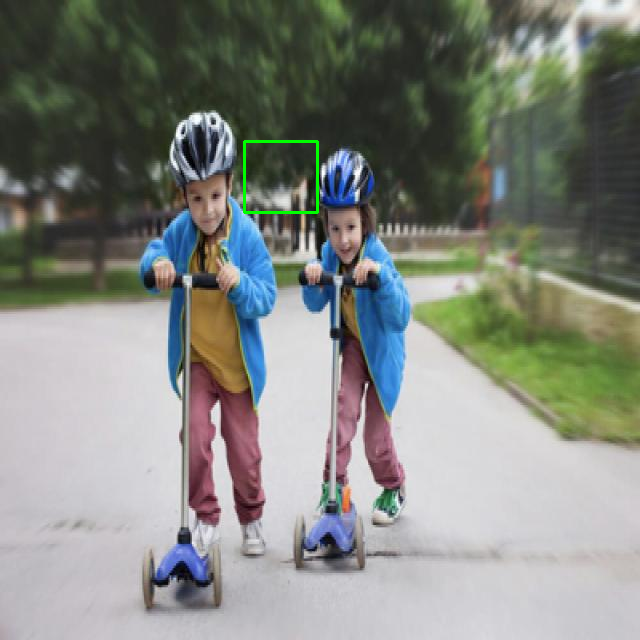

In [53]:
d=detect(image_path="/content/output_folder/test/BikesHelmets104_png.rf.c5bf3b51b2e63bbf4c1f73147d7bb632.jpg")